In [1]:
from __future__ import annotations

from typing import Callable  # NOQA
from typing import TYPE_CHECKING

import numpy as np
from copy import deepcopy

if TYPE_CHECKING:  # pragma: no cover
    from cupy.typing import NDArray as CupyArray  # type: ignore
    from numpy.typing import NDArray as NumpyArray

from blond import (  # NOQA
    Beam,
    DriftSimple,
    MagneticCyclePerTurn,
    Ring,
    Simulation,
    SingleHarmonicRFStation,
    StaticProfile,
    WakeField,
    momentum_compaction_factor,
    proton,
)
from blond.core.beam.beams import ProbeBeam
from blond.experimental.beam_preparation.bucket_filler_functions import (
    multibunch_match_metric_to_hamilton,
)
from blond.experimental.beam_preparation.density_functions import (
    gaussian_density,
)
from blond.experimental.beam_preparation.metric_functions import rms_emittance
from blond.experimental.beam_preparation.semi_empiric_matcher import (
    SemiEmpiricMatcher,
)
from blond.physics.impedances.solvers import PeriodicFreqSolver
from blond.physics.impedances.sources import Resonators
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_simpson  # type: ignore[import-untyped]
from blond.generals.formatting_ import si_format
from blond.beam_preparation.helpers import populate_beam
from blond import AllowPlotting, backend
from blond.experimental.beam_preparation.bucket_filler_functions import (
    hamilton_to_density_by_max,
)
from blond.experimental.beam_preparation.semi_empiric_matcher_extensions.line_density.callables import (
    occupation_per_equipotential_to_density,
    occupation_per_equipotential_to_histogram,
)

Using environment variable BLOND_BACKEND_MODE = python
Changing backend to `Numpy64Bit`


C:\Users\slauber\PycharmProjects\BLonD\blond\experimental\__init__.py:38: ExperimentalFeaturesWarning: 
Importing experimental features. These are under development and are
liable to change or be removed without warning.

  warnings.warn(_msg, ExperimentalFeaturesWarning, stacklevel=1)


# Using the Semi-Empiric Matcher

The `SemiEmpiricMatcher` prepares a **matched** longitudinal beam distribution for BLonD simulations. A matched distribution is stationary in phase space: particles follow closed orbits on constant-Hamiltonian contours and the bunch shape does not evolve turn-by-turn.

The approach is *semi-empiric*: the RF potential well is derived **numerically** from a single simulated turn, while the kinetic (drift) term of the Hamiltonian is computed **analytically** from the machine optics. This hybrid strategy handles arbitrary RF waveforms and impedance contributions without requiring a closed-form expression for the voltage.

## Define the Simulation Context

In [2]:
energy_cycle = MagneticCyclePerTurn.init_from_linspace(
    values=np.linspace(450e9, 470e9, int(1e4)),
    reference_particle=proton,
)

ring = Ring(26658.883)

rf_station = SingleHarmonicRFStation(harmonic=35640, voltage=6e6, phi_rf=0)

drift1 = DriftSimple(orbit_length=26658.883)
drift1.momentum_compaction_factor = momentum_compaction_factor(
    transition_gamma=55.759505
)

beam1 = Beam(intensity=1e9, particle_type=proton)

sim = Simulation.from_locals(locals())

## Generate the Potential Well

To construct the Hamiltonian we need the RF potential well $V(\tau)$. Rather than integrating the RF voltage analytically, we derive it empirically: a zero-energy *probe bunch* is tracked for one turn and the $\Delta E$ kicks it receives are integrated.

A `ProbeBeam` is a massless, zero-intensity beam placed along the time axis at $\Delta E = 0$. It samples the RF phase at equidistant points across the bucket window.

In [3]:
dt = np.linspace(0, 10e-9, 100)

_probe_bunch = ProbeBeam(
    dt=dt,
    particle_type=beam1.particle_type,
    intensity=0,
    reference_total_energy=energy_cycle.get_total_energy_init(),
)
probe_bunch_init = deepcopy(_probe_bunch)

Text(0.5, 0, 'Time (s)')

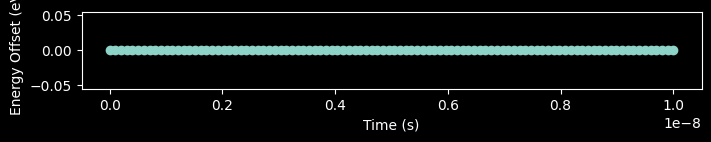

In [4]:
plt.figure(figsize=(8, 1))
probe_bunch_init.plot_scatter()
plt.ylabel("Energy Offset (eV)")
plt.xlabel("Time (s)")

### Tracking the Probe Beam for One Turn

We run exactly one simulation turn. Each probe particle receives an energy kick $\Delta E(\tau)$ from the RF cavity. The revolution period $T_\text{rev}$ is read back from the reference particle and used to normalise the potential in the next step.

In [5]:
probe_bunch_out = deepcopy(_probe_bunch)

deepcopy(sim).run_simulation(
    beams=(probe_bunch_out,),
    n_turns=1,
    show_progressbar=False,
    verbose=False,
)

In [6]:
t_rev = probe_bunch_out.reference.time - probe_bunch_init.reference.time
si_format(t_rev) + "s"

'88.92µs'

### Energy Kicks Received by the Probe Particles

Plotting $\Delta E$ vs. $\tau$ reveals the RF waveform sampled at the probe positions. The sinusoidal shape is the expected response of a single-harmonic RF cavity.

Text(0.5, 0, 'Time (s)')

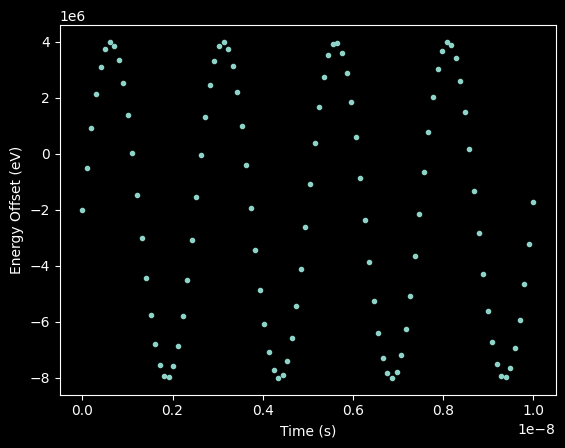

In [7]:
plt.plot(
    probe_bunch_out.dt.array_local, probe_bunch_out.dE.array_local, ".", c="C0"
)
plt.ylabel("Energy Offset (eV)")
plt.xlabel("Time (s)")

### Integrating the Kicks into a Potential Well

The potential well is obtained by integrating the energy kicks along the time axis:

$$V(\tau) = -\int_0^\tau \Delta E(\tau')\,d\tau'$$

A normalisation factor $T_\text{bucket} / T_\text{rev}$ converts from the probe-particle spacing to physical time. The minimum is then shifted to zero so that $V(\tau) \geq 0$. The built-in helper `sim.plot_potential_well_empiric` performs the same calculation internally.

In [8]:
def plot():
    ax = plt.subplot(2, 1, 1)
    plt.plot(
        probe_bunch_init.dt.array_local, probe_bunch_out.dE.array_local, c="C0"
    )
    plt.ylabel("Energy Offset (eV)")

    plt.subplot(2, 1, 2, sharex=ax)
    plt.plot(probe_bunch_init.dt.array_local, potential_well, c="C1")
    plt.ylabel("Potential [arb. unit]")
    plt.xlabel("Time (s)")
    plt.tight_layout()

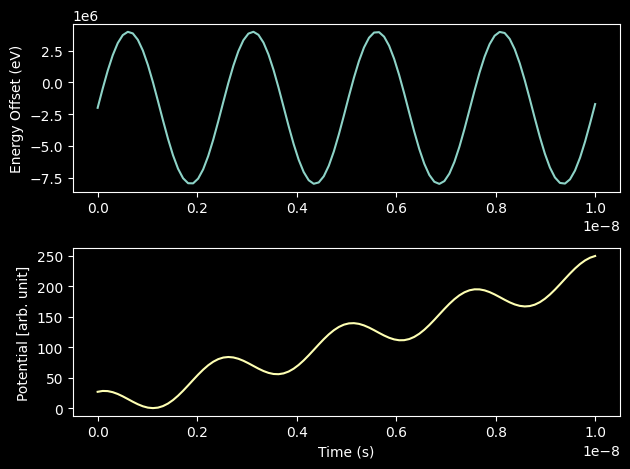

In [9]:
potential_well = -cumulative_simpson(
    probe_bunch_out.dE.copy_as_numpy(),
    initial=0,
) / len(probe_bunch_out.dE.array_local)
norm = (
    probe_bunch_init.dt.array_local[-1] - probe_bunch_init.dt.array_local[0]
) / t_rev
potential_well *= norm
potential_well -= np.min(potential_well)  # make the minimum value 0
plot()

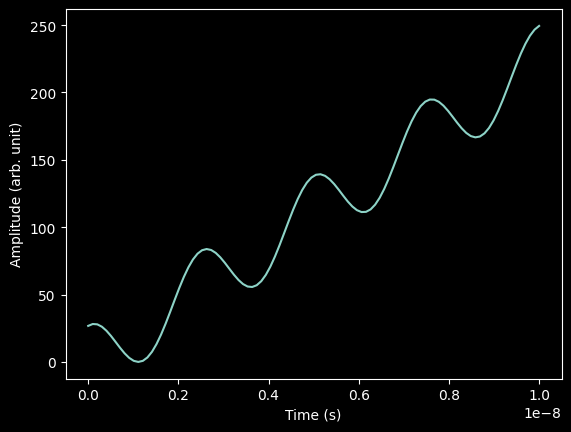

In [10]:
sim.plot_potential_well_empiric(
    dt=probe_bunch_init.dt.array_local,
    particle_type=probe_bunch_init.reference.particle_type,
)

## Construct the Hamiltonian

This is why we call it *semi* empiric matching. The `drift_term` is used in its analytical form.

In [11]:
def plot(hamilton_2D):
    plt.figure(figsize=(6, 5))
    plt.pcolormesh(
        time_grid, deltaE_grid, hamilton_2D, shading="auto", cmap="viridis"
    )
    plt.colorbar(label="Hamiltonian value")
    plt.xlabel("x-axis")
    plt.ylabel("Energy Offset (eV)")
    plt.xlabel("Time (s)")

In [12]:
eta = drift1.eta_0(gamma=probe_bunch_init.reference.gamma)
beta = probe_bunch_init.reference.beta
E0 = probe_bunch_init.reference.total_energy

In [13]:
drift_term = np.abs(eta) / (np.square(beta) * E0)  # [1/eV]

In [14]:
dE_max = np.sqrt(  # automatically derive the plot limit
    (potential_well.max()) / (abs(drift_term))
)

### Building the 2D Phase Space Grid

We evaluate $\mathcal{H}$ on a regular $(\tau, \Delta E)$ mesh. The energy range is bounded by $\Delta E_\text{max}$, the energy at which the separatrix is reached (where the kinetic term equals the peak of the potential), keeping the grid tightly focused on the stable region.

In [15]:
_dE_base = np.linspace(-dE_max, dE_max, 100)
time_grid, deltaE_grid = np.meshgrid(
    probe_bunch_init.dt.array_local, _dE_base, indexing="ij"
)

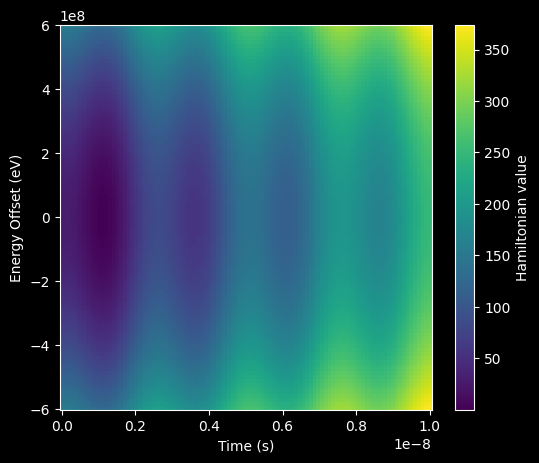

In [16]:
drift_term = np.abs(eta) / (np.square(beta) * E0)
V = potential_well[:, None]
hamilton_2D = 0.5 * drift_term * np.square(deltaE_grid) + V  # [eV]
plot(hamilton_2D)

## Generating a Particle Distribution

Once the Hamiltonian is known, a matched distribution requires only that the particle density $\rho$ is a function of $\mathcal{H}$ alone — each iso-Hamiltonian contour must be uniformly populated. The choice of $\rho(\mathcal{H})$ determines the projected bunch shape.

BLonD provides the built-in `hamilton_to_density_by_max` algorithm. The four steps below show how it works before the full `SemiEmpiricMatcher` API is introduced.

### Algorithm 1: Max Clipping

#### Step 1 — Clip to the Separatrix

Cells with $\mathcal{H} > \mathcal{H}_\text{sep} \cdot f_\text{cut}$ (outside or near the bucket edge) are replaced by the separatrix value. This hard-clips the density to the stable region. The fraction `hamilton_max` (e.g. 90\% of the separatrix value) controls how close to the edge the distribution is allowed to reach.

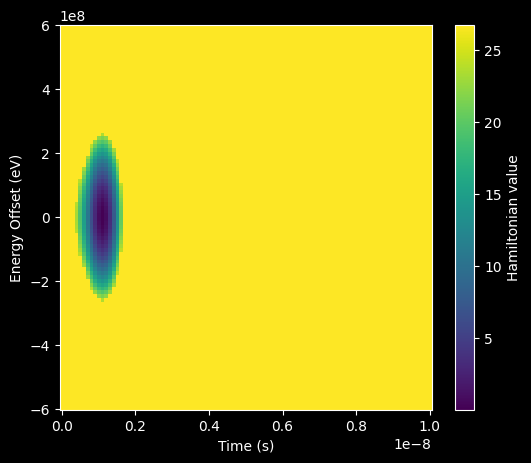

In [17]:
density = deepcopy(hamilton_2D)
select = (0.9 * potential_well[0]) < hamilton_2D
density[select] = potential_well[0]
plot(density)

#### Step 2 — Invert the Distribution

After clipping, low-Hamiltonian (core) cells have small values and edge cells have large values. We invert by computing `density_max - density` so that the bunch core becomes the most densely populated region.

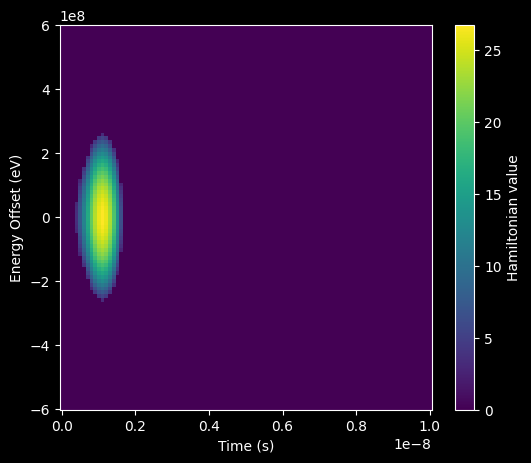

In [18]:
density = density.max() - density
plot(density)

#### Step 3 — Shape with an Exponent

Raising the inverted density to a power `n` (the `density_modifier`) sharpens the profile. Higher exponents concentrate more particles near the core and produce a more Gaussian-like line-density projection. The default is `n = 2`.

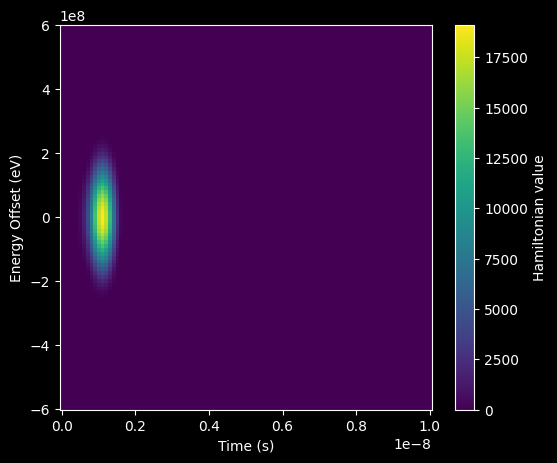

In [19]:
exponent = 3
density = density**exponent
plot(density)

#### Step 4 — Sample Macro-Particles

The final density grid is used as a 2D probability distribution from which macro-particles are drawn via rejection sampling. The resulting beam has `n_macroparticles` particles distributed according to the computed density.

In [20]:
beam = deepcopy(_probe_bunch)
populate_beam(
    beam=beam,
    time_grid=time_grid.T,
    deltaE_grid=deltaE_grid.T,
    density_grid=density.T,
    n_macroparticles=int(1e6),
    seed=0,
)

### Verifying the Match

A well-matched beam should look nearly identical after many turns. We run a short simulation and compare the phase-space portrait at turn 0 and after one passage. Significant filamentation or shape change indicates a mismatch.

In [21]:
def plot_before():
    ax = plt.subplot(1, 2, 1)
    plt.title("Turn 0")
    beam.plot_hist2d(
        range=((time_grid.min(), 2e-9), (deltaE_grid.min(), deltaE_grid.max()))
    )
    return ax


def plot_after(ax):
    plt.subplot(1, 2, 2, sharex=ax, sharey=ax)
    plt.title(f"Turn {sim_tmp.turn_i.value}")
    beam.plot_hist2d(
        range=((time_grid.min(), 2e-9), (deltaE_grid.min(), deltaE_grid.max()))
    )

In [22]:
backend.set_specials("cpp")
sim_tmp = deepcopy(sim)
kwargs = dict(show_progressbar=False, verbose=False)

Set special to `cpp`


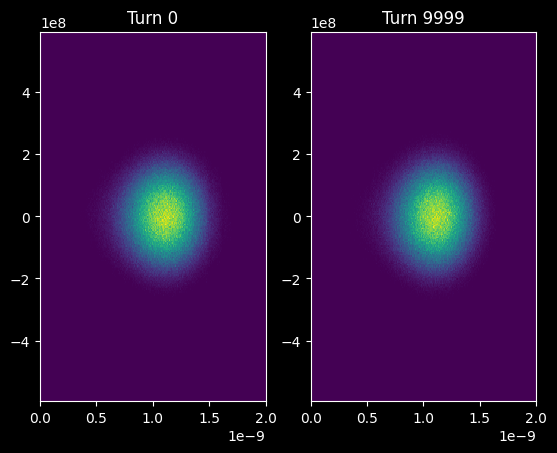

In [23]:
ax = plot_before()
sim_tmp.run_simulation(beams=(beam,), **kwargs)
plot_after(ax)

### Providing a Custom Algorithm

Not all use cases are covered by `hamilton_to_density_by_max`. You can supply any callable with the signature below to `SemiEmpiricMatcher` via `hamilton_to_density_function`. Additional keyword arguments are forwarded through `hamilton_to_density_kwargs`.

In [24]:
def hamilton_to_density_by_user(
    time_grid: NumpyArray,
    deltaE_grid: NumpyArray,
    hamilton_2D: NumpyArray,
    your_argument_01,  # add user defined arguments
    your_argument_02,  # add user defined arguments
) -> NumpyArray: ...

### Using the SemiEmpiricMatcher API

The four steps above are wrapped inside `SemiEmpiricMatcher`. Pass it to `sim.prepare_beam` and it handles probe tracking, potential integration, Hamiltonian construction, and particle sampling in a single call.

Setting `maxiter_intensity_effects=0` disables the self-consistent loop for space-charge and impedance-driven potential distortion. Increase it to account for intensity effects.

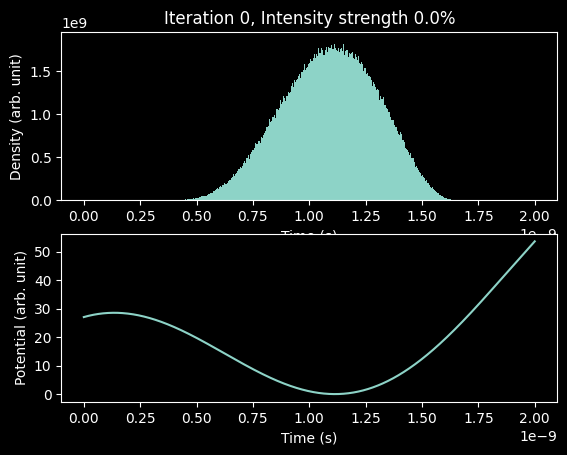

In [25]:
beam1 = deepcopy(_probe_bunch)
sim.prepare_beam(
    beam=beam1,
    preparation_routine=SemiEmpiricMatcher(
        time_limit=(0, 2.0e-9),
        n_macroparticles=1e6,
        seed=0,
        maxiter_intensity_effects=0,
        hamilton_to_density_function=hamilton_to_density_by_max,
        hamilton_to_density_kwargs=dict(
            density_modifier=2.0,  # Controls density profile sharpness
            hamilton_max=0.9 * potential_well[0],  # Hamiltonian cutoff [eV]
        ),
        animate=True,
    ),
)

## Validating the SemiEmpiricMatcher Output

We repeat the before/after comparison — phase-space portrait at turn 0 vs. after one passage — but now starting from a beam generated by `SemiEmpiricMatcher`. A stable, non-filamenting portrait confirms that the matching succeeded.

In [ ]:
ax = plt.subplot(1, 2, 1)
plt.title("Turn 0")
beam1.plot_hist2d(
    range=((time_grid.min(), 2e-9), (deltaE_grid.min(), deltaE_grid.max()))
)
backend.set_specials("cpp")
sim_tmp = deepcopy(sim)
sim_tmp.run_simulation(
    beams=(beam1,),
    show_progressbar=False,
    verbose=False,
)

plt.subplot(1, 2, 2, sharex=ax, sharey=ax)
plt.title(f"Turn {sim_tmp.turn_i.value}")
beam1.plot_hist2d(
    range=((time_grid.min(), 2e-9), (deltaE_grid.min(), deltaE_grid.max()))
)

## Fitting Line Densities

In many operational scenarios the target bunch shape must match a **measured** wall-current monitor (WCM) profile. The `ProfileMatcherAddon` extension solves for the *occupation-per-equipotential* vector $\mathbf{p}$ such that the projected line density reproduces the measured histogram.

The following cells build up the concept from first principles before demonstrating the full API.

In [ ]:
def plot(hamilton_2D):
    plt.figure(figsize=(6, 5))
    plt.subplot(3, 1, 1)
    plt.plot(occupation_per_equipotential, label="Population State", c="C0")
    plt.legend()
    plt.subplot(3, 1, 2)
    plt.pcolormesh(hamilton_2D.T, shading="auto", cmap="viridis")
    plt.subplot(3, 1, 3)
    plt.plot(histogram, label="Histogram", c="C1")
    plt.legend()
    plt.tight_layout()

In [ ]:
idx = np.argmax(probe_bunch_init.dt.array_local > 2e-9)
hamilton_2D = hamilton_2D[:idx, :]

In [ ]:
density = np.empty_like(hamilton_2D)
occupation_per_equipotential = np.zeros(hamilton_2D.shape[0])
occupation_per_equipotential[len(occupation_per_equipotential) // 4] = 1
occupation_per_equipotential_to_density(
    occupation_per_equipotential=occupation_per_equipotential,
    potential_2D=hamilton_2D,
    density_write=density,
)

histogram = occupation_per_equipotential_to_histogram(
    occupation_per_equipotential=occupation_per_equipotential,
    potential_2D=hamilton_2D,
)

### Visualising the Density from an Occupation Vector

The 3-panel plot shows how a single non-zero entry in $\mathbf{p}$ (population concentrated on one equipotential shell) maps to a 2D density and then to a 1D line-density histogram. A full distribution is a superposition of contributions from all shells.

In [ ]:
plot(density)

### Fitting a Measured Profile with `ProfileMatcherAddon`

`ProfileMatcherAddon` wraps an optimisation loop that finds the occupation vector $\mathbf{p}$ whose projected histogram best matches the target. It plugs directly into `SemiEmpiricMatcher` as a drop-in `hamilton_to_density_function`, so the rest of the workflow is unchanged.

Key hyperparameters:

| Parameter | Effect |
|-----------|--------|
| `smoothness` | Regularisation strength — higher values enforce a smoother occupation vector |
| `atol` | Convergence tolerance on the histogram residual |
| `recenter` | Shift the fitted distribution to the bunch centre before sampling |

In [ ]:
from __future__ import annotations

# pragma: no cover
from typing import TYPE_CHECKING

import matplotlib.pyplot as plt
import numpy as np

from blond import (
    Beam,
    BeamObservationOncePerTurn,
    DriftSimple,
    RFStationPhaseObservation,
    Ring,
    Simulation,
    SingleHarmonicRFStation,
    momentum_compaction_factor,
    proton,
)
from blond.cycles.magnetic_cycle import MagneticCyclePerTurn
from blond.experimental import ProfileMatcherAddon, SemiEmpiricMatcher
from blond.generals.cupy.no_cupy_import import copy_to_cpu

In [ ]:
def get_test_profile(noisy=False):
    """
    Create a histogram that looks like a measurement.

    Parameters
    ----------
    noisy
        If it should be generated with or without noise.

    Returns
    -------
    hist_x
        Histogram time axis.
    hist_y
        Histogram amplitude.
    """
    # Parameters
    mean = 2.5e-9 / 2  # Mean of the distribution
    std_dev = 2.5e-9 / 30  # Standard deviation
    size = 10000  # Number of data points

    if noisy:  # pragma: no cover
        # Generate random data from a Gaussian distribution
        data = np.random.normal(loc=mean, scale=std_dev, size=size)

        # Get the histogram (density=False for raw counts)
        hist_y, bin_edges = np.histogram(data, bins=512, density=False)
        hist_x = bin_edges[0:-1] + np.diff(bin_edges[:2])[0] / 2
    else:
        hist_x = np.linspace(0, 2.5e-9, 100)
        hist_y = (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(
            -((hist_x - mean) ** 2) / (2 * std_dev**2)
        )
    return hist_x, hist_y

In [ ]:
ring = Ring(26658.883)

rf_station = SingleHarmonicRFStation()
rf_station.harmonic = 35640
rf_station.voltage = 6e6
rf_station.phi_rf_design = 0

values = np.linspace(450e9, 450e9, int(1e3) + 1)
energy_cycle = MagneticCyclePerTurn(
    value_init=values[0],
    values_after_turn=values[1:],
    reference_particle=proton,
)

drift1 = DriftSimple(
    orbit_length=26658.883,
)
drift1.momentum_compaction_factor = momentum_compaction_factor(
    transition_gamma=55.759505
)
beam1 = Beam(
    intensity=1e9,
    particle_type=proton,
)

sim = Simulation.from_locals(locals())

In [ ]:
hist_x, hist_y = get_test_profile()
matcher_addon = ProfileMatcherAddon(hist_x=hist_x, hist_y=hist_y)
matcher_addon.smoothness = 0.01
matcher_addon.atol = 1e-3
matcher_addon.recenter = True
matcher_addon.animate_fitting = False
matcher_addon.plot_result = True
matcher_addon.plot_result_blocking = True

In [ ]:
sim.prepare_beam(
    beam=beam1,
    preparation_routine=SemiEmpiricMatcher(
        time_limit=(0, 2.5e-9),
        n_macroparticles=int(1e6),
        seed=0,
        maxiter_intensity_effects=0,
        internal_grid_shape=(1024, 1024),
        hamilton_to_density_function=matcher_addon.hamilton_to_density_function,
        hamilton_to_density_kwargs=dict(),
        animate=False,
    ),
)

## Known Limitations and Open Items

The following topics are implemented or partially implemented but not covered in this tutorial:

- **Intensity effects** — self-consistent iteration over impedance-driven potential distortion is available via `maxiter_intensity_effects > 0`
- **Multiple RF buckets** — partial support as of March 2024; multi-bucket scenarios may need manual adjustments
- **Ill-constrained line densities** — the optimiser can diverge if the target histogram is wider than the bucket or has features outside the separatrix
- **Unstable operating points** — matching cannot converge above the intensity threshold
- Anti-aliasing in `occupation_per_equipotential_to_density`
- Histogram recentering edge cases
- State-vector smoothing strategies
- Iterative solver for line-density fitting

## Roadmap

Planned improvements and research directions:

- Account for synchrotron radiation damping and quantum excitation
- Handle parametric resonances near low-order resonance conditions
- Robust multi-drift / multi-RF support
- Fully empiric implementation without an analytic drift term
- Hybrid Lie-algebra + per-element numeric potential well
- Per-bucket sparse matching with coupled-bunch intensity effects

## Conclusion

- `SemiEmpiricMatcher` reliably produces matched distributions and is ready for user testing
- Custom `hamilton_to_density` functions allow adaptation to specialised use cases
- `ProfileMatcherAddon` extends the matcher to reproduce measured bunch profiles

### See Also

- [Documentation: Semi-Empiric Matcher](https://blond-code.docs.cern.ch/models_new/semi_empiric_matcher.html)
- `blond/examples/scripts/EX_01_Acceleration_match_density.py`
- `blond/examples/scripts/EX_09_Semi_empiric_matcher.py`
- `blond/experimental/beam_preparation/semi_empiric_matcher.py`

## Contributing and Feedback

Bug reports and feature requests are welcome. If you encounter unexpected behaviour or have suggestions for improving the matcher, please open an issue on the BLonD repository.

---

*Thank you for reading this tutorial.*